In [ ]:
import os
import pandas as pd
import re

import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
# Load dataset
dataset_dir = '../raw_dataset'
dataset_paths = {
    'folio': os.path.join(dataset_dir, 'Folio'),
    'logiqa': os.path.join(dataset_dir, 'LogiQA'),
    'proofwriter': os.path.join(dataset_dir, 'ProofWriter'),
    'reclor': os.path.join(dataset_dir, 'ReClor'),
    'ruletaker': os.path.join(dataset_dir, 'RuleTaker')
}

dataset = []

for name, parent_dir in dataset_paths.items():
    for partition in ['train', 'valid', 'test']:
        path = os.path.join(parent_dir, f'{name}_{partition}.json')

        if os.path.exists(path):
            df = pd.read_json(path)
            df['source_name'] = name
            df['partition'] = partition

            df = df.rename(columns=lambda x: x.replace('premise', 'premises').replace('premisess', 'premises'))

            def clean_none_values(val):
                if isinstance(val, str):
                    if val.strip() == 'None':
                        return None
                return val

            df = df.apply(clean_none_values)

            dataset.append(df)
        else:
            raise FileNotFoundError(f'{path} is not existed')

df = pd.concat(dataset, ignore_index=True)

print("Columns:", df.columns.tolist())

Columns: ['id', 'story_id', 'nat_premises', 'nat_conclusion', 'fol_premises', 'fol_conclusion', 'label', 'source_name', 'partition']


In [7]:
df.head()

,id,story_id,nat_premises,nat_conclusion,fol_premises,fol_conclusion,label,source_name,partition
0,folio_train_0,folio_406,All people who regularly drink coffee are depe...,Rina doesn't want to be addicted to caffeine o...,"∀x (DrinkRegularly(x, coffee) → IsDependentOn(...","¬WantToBeAddictedTo(rina, caffeine) ∨ ¬AwareTh...",True,folio,train
1,folio_train_1,folio_406,All people who regularly drink coffee are depe...,Rina either doesn't want to be addicted to caf...,"∀x (DrinkRegularly(x, coffee) → IsDependentOn(...","¬(¬WantToBeAddictedTo(rina, caffeine) ↔ ¬Aware...",True,folio,train
2,folio_train_2,folio_406,All people who regularly drink coffee are depe...,Rina either regularly drinks coffee or is unaw...,"∀x (DrinkRegularly(x, coffee) → IsDependentOn(...","¬(DrinkRegularly(rina, coffee) ↔ ¬AwareThatDru...",False,folio,train
3,folio_train_3,folio_406,All people who regularly drink coffee are depe...,If Rina either doesn't want to be addicted to ...,"∀x (DrinkRegularly(x, coffee) → IsDependentOn(...","((¬WantToBeAddictedTo(rina, caffeine) ∧ ¬Aware...",True,folio,train
4,folio_train_4,folio_8,Miroslav Venhoda was a Czech choral conductor ...,Miroslav Venhoda loved music.,Czech(miroslav) ∧ ChoralConductor(miroslav) ∧ ...,"Love(miroslav, music)",Uncertain,folio,train


In [8]:
df.describe()

,id,story_id,nat_premises,nat_conclusion,fol_premises,fol_conclusion,label,source_name,partition
count,135749,135749,135749,135749,1043,1043,135749,135749,135749
unique,135749,57143,78283,15545,504,1042,3,5,3
top,folio_train_0,folio_316,Anne is green. Anne is quiet. Anne is round. B...,Erin is young.,∀x (MindReading(x) ∧ (BrainReading(x) ⊕ BrainD...,ProfessionalCenterback(stephenCurry),True,ruletaker,train
freq,1,10,13,354,6,2,74195,62446,97361


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135749 entries, 0 to 135748
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   id              135749 non-null  object
 1   story_id        135749 non-null  object
 2   nat_premises    135749 non-null  object
 3   nat_conclusion  135749 non-null  object
 4   fol_premises    1043 non-null    object
 5   fol_conclusion  1043 non-null    object
 6   label           135749 non-null  object
 7   source_name     135749 non-null  object
 8   partition       135749 non-null  object
dtypes: object(9)
memory usage: 9.3+ MB


In [10]:
df.nunique()

id                135749
story_id           57143
nat_premises       78283
nat_conclusion     15545
fol_premises         504
fol_conclusion      1042
label                  3
source_name            5
partition              3
dtype: int64

In [11]:
def split_sentences(text):
    return [s.strip() for s in re.split(r'[.\n]', text) if s.strip()]

def tokenize(text):
    return text.lower().split()

df['sentences'] = df['nat_premises'].apply(split_sentences)
df['tokens'] = df['nat_premises'].apply(tokenize)
df['sentence_count'] = df['sentences'].apply(len)
df['token_count'] = df['tokens'].apply(len)

print("Final Columns:", df.columns.tolist())

Final Columns: ['id', 'story_id', 'nat_premises', 'nat_conclusion', 'fol_premises', 'fol_conclusion', 'label', 'source_name', 'partition', 'sentences', 'tokens', 'sentence_count', 'token_count']


In [12]:
def tokenize(text):
    return text.lower().split()

all_words = [word for words in df['nat_premises'].apply(tokenize) for word in words]
vocab = set(all_words)

print('Total samples: ', len(df))
print('Vocabulary size: ', len(vocab))

Total samples:  135749
Vocabulary size:  54490


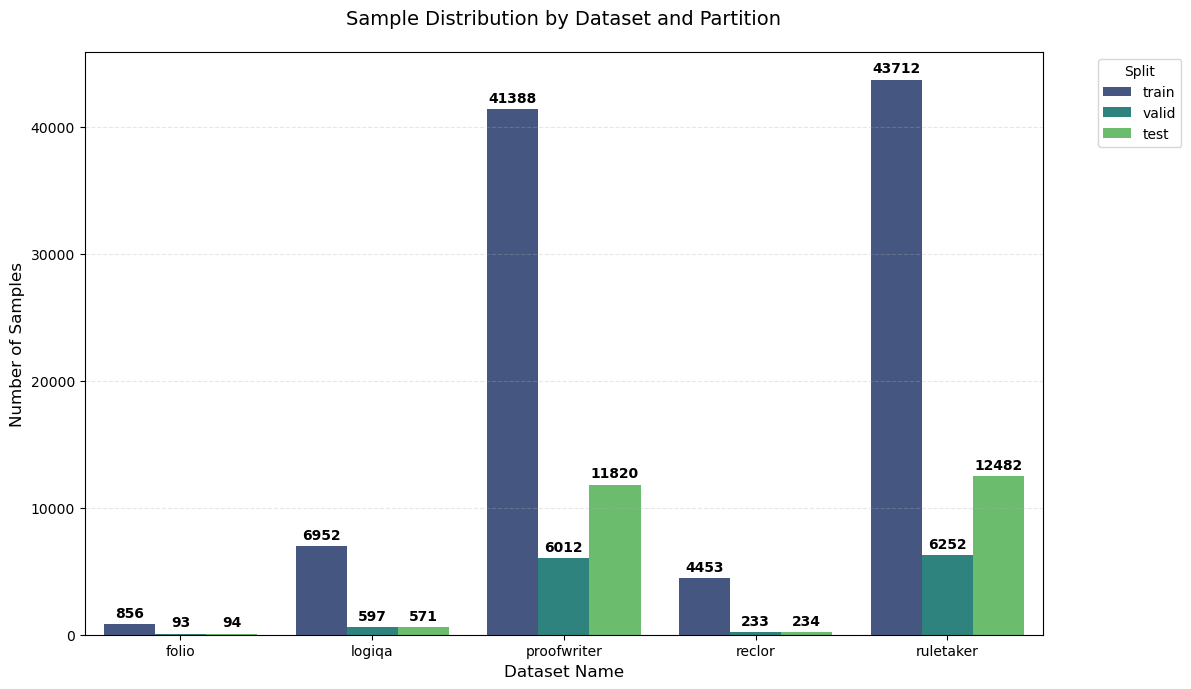

In [13]:
# Number of samples
plt.figure(figsize=(12, 7))
ax = sns.countplot(data=df, x='source_name', hue='partition', palette='viridis')

for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10, fontweight='bold')

plt.title("Sample Distribution by Dataset and Partition", fontsize=14, pad=20)
plt.xlabel("Dataset Name", fontsize=12)
plt.ylabel("Number of Samples", fontsize=12)
plt.legend(title='Split', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()

plt.show()

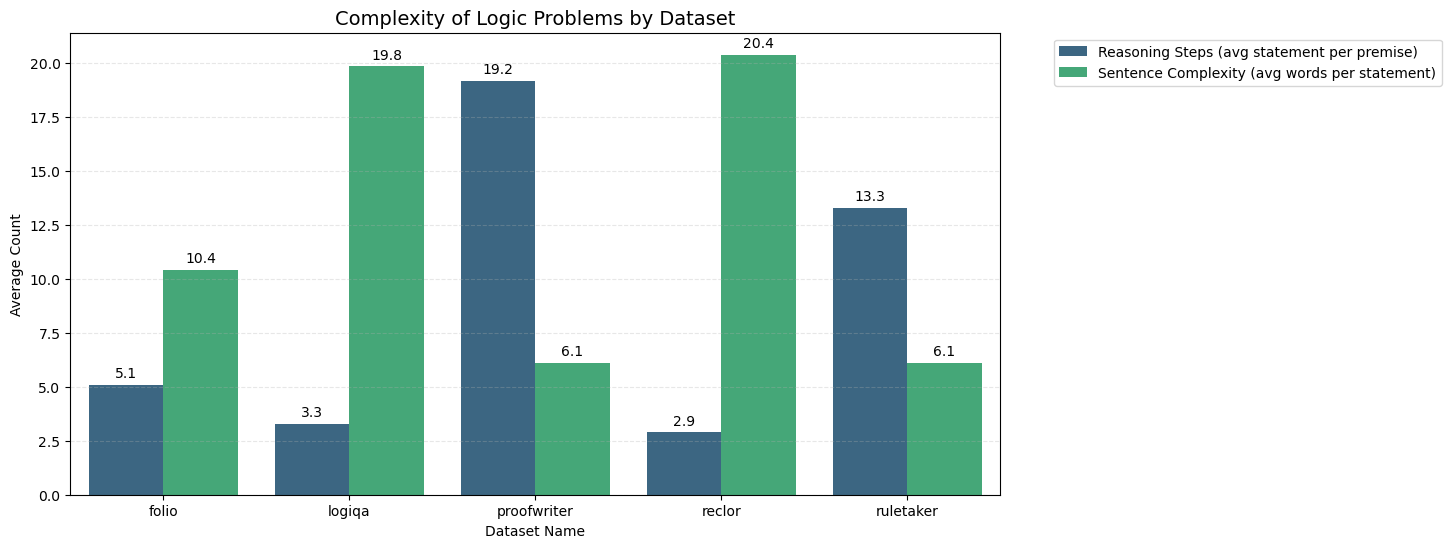

In [15]:
# Average number of words in each statement, and average number of statements in each premise
summary_df = df.groupby('source_name').agg({
    'token_count': 'sum',
    'sentence_count': 'sum',
    'id': 'count'
}).reset_index()

summary_df['avg_statements_per_premise'] = (summary_df['sentence_count'] / summary_df['id']).round(2)
summary_df['avg_words_per_statement'] = (summary_df['token_count'] / summary_df['sentence_count']).round(2)

complexity_df = summary_df[['source_name', 'avg_statements_per_premise', 'avg_words_per_statement']]
complexity_df.columns = ['Source', 'Reasoning Steps (avg statement per premise)', 'Sentence Complexity (avg words per statement)']
plot_df = complexity_df.melt(id_vars='Source', var_name='Metric', value_name='Value')


plt.figure(figsize=(12, 6))
ax = sns.barplot(data=plot_df, x='Source', y='Value', hue='Metric', palette='viridis')

for container in ax.containers:
    ax.bar_label(container, padding=3, fmt='%.1f')

plt.title("Complexity of Logic Problems by Dataset", fontsize=14)
plt.ylabel("Average Count")
plt.xlabel("Dataset Name")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

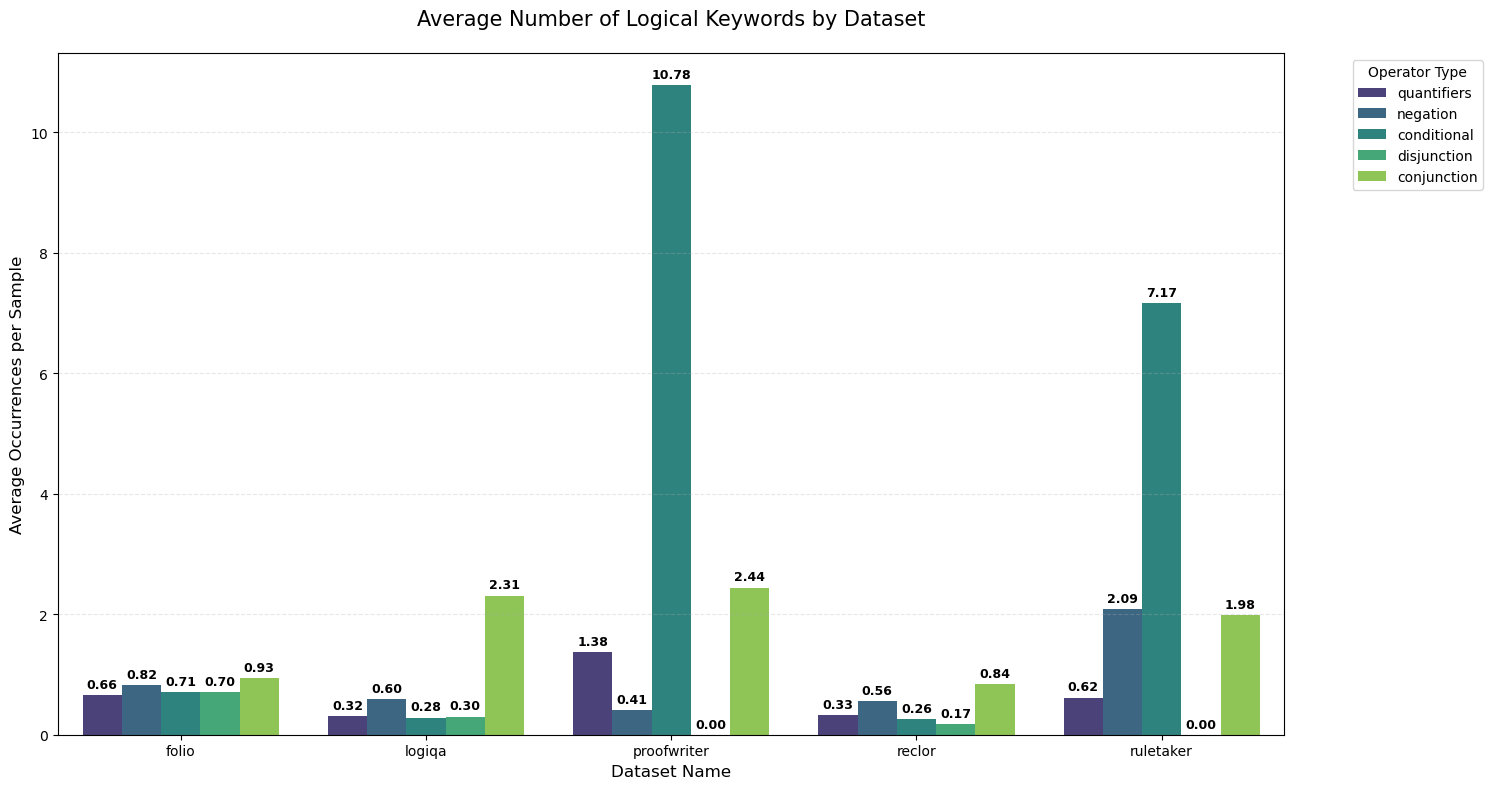

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

logic_dict = {
    "quantifiers": ["all", "some", "every", "none"],
    "negation": ["not", "no", "never", "neither"],
    "conditional": ["if", "then", "unless"],
    "disjunction": ["or"],
    "conjunction": ["and"]
}

def extract_logic_features(text):
    words = text.lower().split()
    features = {}

    for k, vocab in logic_dict.items():
        features[k] = sum(word in vocab for word in words)

    return pd.Series(features)

logic_features = df["nat_premises"].apply(extract_logic_features)
df = pd.concat([df, logic_features], axis=1)

logic_cols = list(logic_dict.keys())
logic_density = df.groupby('source_name')[logic_cols].mean().reset_index()

plot_df = logic_density.melt(id_vars='source_name', var_name='Logical_Operator', value_name='Avg_Frequency')

plt.figure(figsize=(15, 8))
ax = sns.barplot(data=plot_df, x='source_name', y='Avg_Frequency', hue='Logical_Operator', palette='viridis')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=9, fontweight='bold')

plt.title("Average Number of Logical Keywords by Dataset", fontsize=15, pad=20)
plt.ylabel("Average Occurrences per Sample", fontsize=12)
plt.xlabel("Dataset Name", fontsize=12)
plt.legend(title="Operator Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()

plt.show()

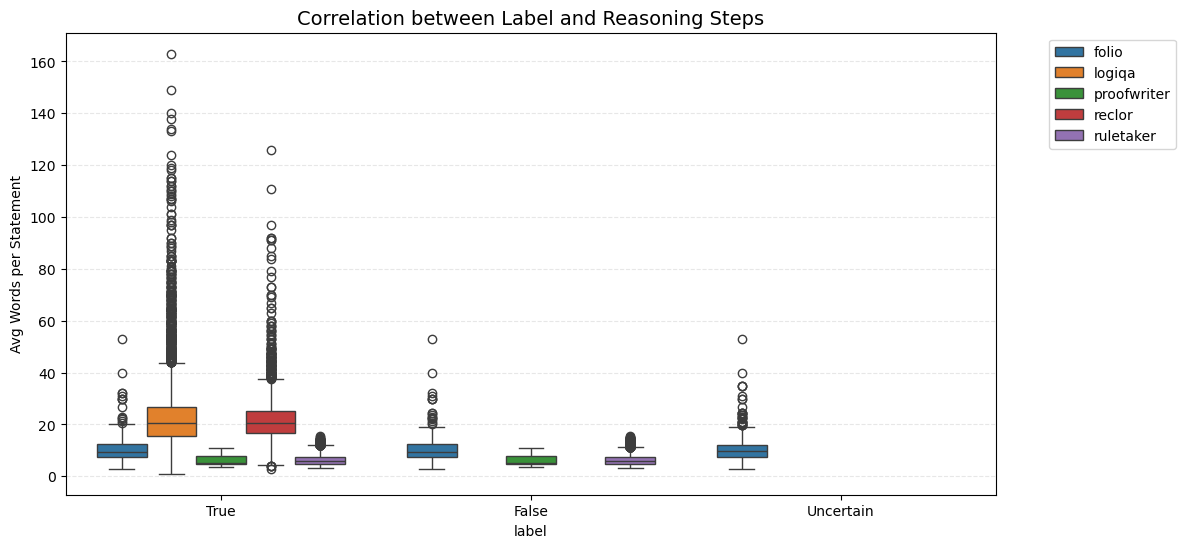

In [17]:
# Label Correlation with average words per statement
df['avg_words_per_statement'] = df['token_count'] / df['sentence_count'].replace(0, 1)

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='label', y='avg_words_per_statement', hue='source_name')

plt.title("Correlation between Label and Reasoning Steps", fontsize=14)
plt.ylabel("Avg Words per Statement")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()